# Modeling Methods

In this document, I demonstrate how we can use compartmental models and agent-based models for epidemic modeling.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# ── A shared house style for every chart below ───────────────────────────────
# Defining the look once keeps the figures consistent and out of "default
# matplotlib" territory. None of this touches the underlying simulations.
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# Semantic palette: each compartment keeps the same colour across every figure.
PALETTE = {
    's': '#3B7A9E',   # Susceptible — calm blue
    'e': '#E1A730',   # Exposed     — amber
    'i': '#D1495B',   # Infected    — clay red
    'q': '#7B6CA8',   # Quarantined — muted violet
    'r': '#5C8A6A',   # Recovered   — sage green
}
LABELS = {'s': 'Susceptible', 'e': 'Exposed', 'i': 'Infected',
          'q': 'Quarantined', 'r': 'Recovered'}

INK    = '#1F2A30'   # near-black for text
MUTED  = '#7A8891'   # secondary text / ticks
ACCENT = '#22333B'   # threshold / reference lines
GRID   = '#E4E8EB'
PAPER  = '#FBFAF7'   # warm off-white page tint

# A low->high sequential ramp (blue -> amber -> red) for the sweep scatters.
SEQ = LinearSegmentedColormap.from_list('seir_seq', ['#3B7A9E', '#E1A730', '#D1495B'])

mpl.rcParams.update({
    'figure.facecolor':  PAPER,
    'axes.facecolor':    PAPER,
    'savefig.facecolor': PAPER,
    'figure.dpi':        130,
    'savefig.dpi':       130,
    'savefig.bbox':      'tight',

    'font.family':       ['Avenir Next', 'Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size':         12,
    'text.color':        INK,

    'axes.edgecolor':    '#C7CED2',
    'axes.linewidth':    1.0,
    'axes.labelcolor':   INK,
    'axes.labelpad':     8,
    'axes.titlecolor':   INK,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.axisbelow':    True,

    'xtick.color':       MUTED,
    'ytick.color':       MUTED,
    'xtick.labelsize':   10.5,
    'ytick.labelsize':   10.5,
    'xtick.major.size':  0,
    'ytick.major.size':  0,

    'axes.grid':         True,
    'axes.grid.axis':    'y',
    'grid.color':        GRID,
    'grid.linewidth':    1.0,

    'legend.frameon':    False,
    'legend.fontsize':   11,
    'lines.solid_capstyle': 'round',
})


def titled(ax, title, subtitle=None):
    """Left-aligned editorial title with an optional grey deck above the plot."""
    ax.set_title(title, loc='left', fontsize=15.5, fontweight='bold',
                 color=INK, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0.0, 1.015, subtitle, transform=ax.transAxes,
                fontsize=10.5, color=MUTED, ha='left', va='bottom')


def end_labels(ax, x_label, items, gap_frac=0.075):
    """Colour-matched labels at data-x ``x_label``, nudged apart to avoid overlap.

    items: list of (y_value, text, color). Call once the y-limits are final and
    leave room on the right via set_xlim so the labels are not clipped.
    """
    lo, hi = ax.get_ylim()
    gap = (hi - lo) * gap_frac
    items = sorted(items, key=lambda it: it[0])
    ys = [it[0] for it in items]
    for j in range(1, len(ys)):                 # push upward to keep a min gap
        if ys[j] - ys[j - 1] < gap:
            ys[j] = ys[j - 1] + gap
    for (_, text, color), y_text in zip(items, ys):
        ax.text(x_label, y_text, text, va='center', ha='left',
                fontsize=10.5, fontweight='bold', color=color, clip_on=False)


## The SIR Model

 Let's start with the simplest possible compartmental model, demonstrating the transition between susceptible, infected, and recovered.

In [3]:
# We begin by defining variables.
N = 100.0       # Total population
S_0 = 99        # Initial susceptible
I_0 = 1         # Initial infected
R_0 = 0         # Initial recovered
beta  = 0.4     # Infection rate
gamma = 0.1     # Recovery rate
num_days = 100  # Simulation length

In [4]:
# Next we define transition rates. At every timestep, we use s_t, i_t, r_t to
# determine the transition percentages for the next timestep.
def get_delta_S_t(S_t, I_t):
    return -1 * beta * S_t * I_t / N
def get_delta_I_t(S_t, I_t):
    return (beta * S_t * I_t / N) - (gamma * I_t)
def get_delta_R_t(I_t):
    return gamma * I_t

In [5]:
# Now we run the simulation for 100 timesteps.
sir_data = {
    's': [S_0],
    'i': [I_0],
    'r': [R_0],
}

for _ in range(num_days - 1):

    # Get deltas.
    dst = get_delta_S_t(sir_data['s'][-1], sir_data['i'][-1])
    dit = get_delta_I_t(sir_data['s'][-1], sir_data['i'][-1])
    drt = get_delta_R_t(sir_data['i'][-1])

    # Apply deltas.
    S_t = sir_data['s'][-1] + dst
    I_t = sir_data['i'][-1] + dit
    R_t = sir_data['r'][-1] + drt

    # Record new values.
    sir_data['s'].append(S_t)
    sir_data['i'].append(I_t)
    sir_data['r'].append(R_t)

# Print basic results.
print(f'Total Infected: {round(sir_data['r'][-1])}')

Total Infected: 98


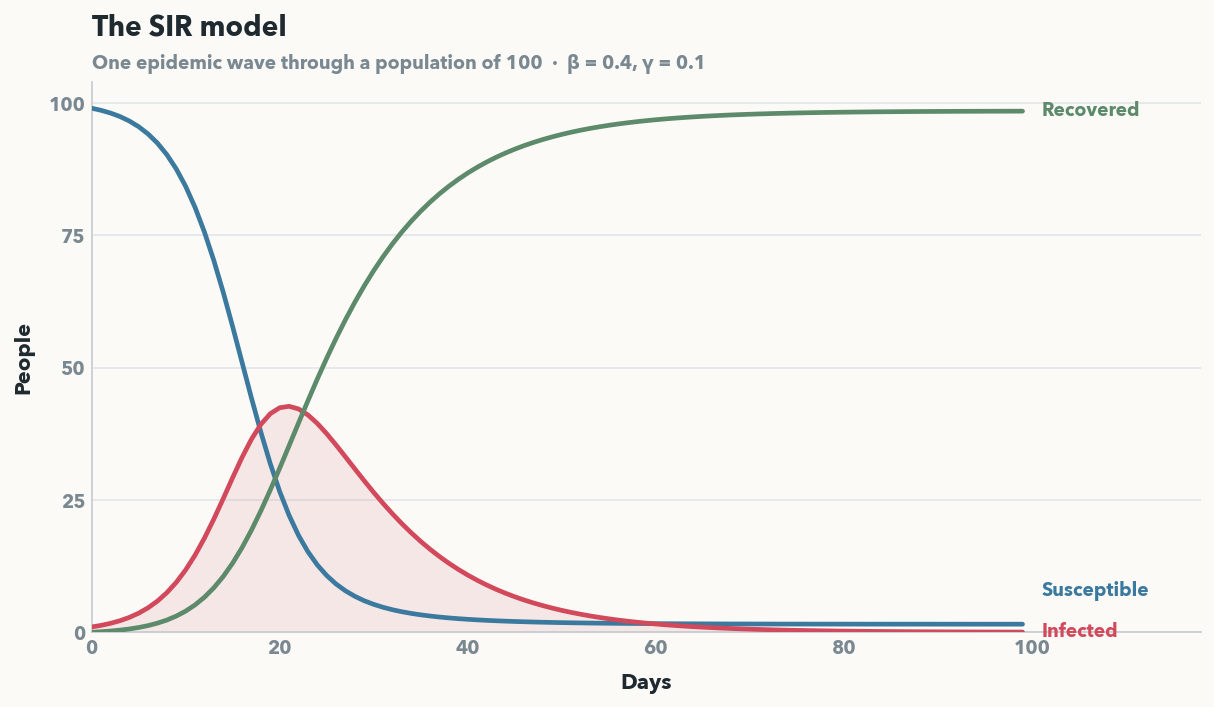

In [6]:
# Graph the data.
t = np.arange(num_days)
fig, ax = plt.subplots(figsize=(9.5, 5.6))

for key in ('s', 'i', 'r'):
    ax.plot(t, sir_data[key], color=PALETTE[key], linewidth=2.6, zorder=3)

# Give the infected wave a little weight and call out its peak.
i_arr = np.array(sir_data['i'])
ax.fill_between(t, i_arr, color=PALETTE['i'], alpha=0.10, zorder=2)
# peak = int(i_arr.argmax())
# ax.scatter([peak], [i_arr[peak]], s=40, color=PALETTE['i'],
#            edgecolor=PAPER, linewidth=1.4, zorder=5)
# ax.annotate(f'peak: {round(i_arr[peak])} infected on day {peak}',
#             xy=(peak, i_arr[peak]), xytext=(peak + 8, i_arr[peak] + 14),
#             fontsize=10, color=PALETTE['i'], fontweight='bold', va='center',
#             arrowprops=dict(arrowstyle='-', color=PALETTE['i'], lw=1, alpha=0.55))

titled(ax, 'The SIR model',
       'One epidemic wave through a population of 100  ·  β = 0.4, γ = 0.1')
ax.set_xlabel('Days')
ax.set_ylabel('People')
ax.set_xlim(0, num_days)
ax.set_ylim(0, 104)
ax.set_yticks([0, 25, 50, 75, 100])

# Direct labels in place of a boxed legend.
end_labels(ax, num_days + 1, [
    (sir_data['s'][-1], LABELS['s'], PALETTE['s']),
    (sir_data['i'][-1], LABELS['i'], PALETTE['i']),
    (sir_data['r'][-1], LABELS['r'], PALETTE['r']),
])
ax.set_xlim(0, num_days * 1.18)

plt.tight_layout()
plt.show()


### Reproduction Number

As long as the ratio between $\beta$ and $\gamma$ stays the same (the reproduction number), the shape of the curve doesn't actually change. That is, the same number of people get infected when $\beta = 0.4$ and $\gamma = 0.1$ vs when $\beta = 0.8$ and $\gamma = 0.2$. The one difference is that the latter scenario evolves much faster - we reach the maximum `I_t` twice as fast as in the first scenario.

In my previous article, I stated that the infection only becomes serious when $\beta > \gamma$ (ie when $R_0 < 1$). When the two values are equal or when beta is less than gamma, relatively few people become infected. Below you'll see the relationship between $R_0$ and the total percentage of the population that becomes infected, clearly demonstrating this principle.

In [7]:
# Loop that tests different R_0 values.
test_betas  = (np.array(range(10)) + 1) / 10.0
test_gammas = (np.array(range(10)) + 1) / 10.0

sir_results = []

for curr_beta in test_betas:
    for curr_gamma in test_gammas:

        repro_num = curr_beta / curr_gamma

        sir_data = {
            's': [S_0],
            'i': [I_0],
            'r': [R_0],
        }

        # Using an extra long range to correct for stretched timescales.
        for _ in range(1000):

            # Get deltas.
            dst = -1 * curr_beta * sir_data['s'][-1] * sir_data['i'][-1] / N
            dit = (curr_beta * sir_data['s'][-1] * sir_data['i'][-1] / N) - (curr_gamma * sir_data['i'][-1])
            drt = curr_gamma * sir_data['i'][-1]

            # Apply deltas.
            S_t = sir_data['s'][-1] + dst
            I_t = sir_data['i'][-1] + dit
            R_t = sir_data['r'][-1] + drt

            # Record new values.
            sir_data['s'].append(S_t)
            sir_data['i'].append(I_t)
            sir_data['r'].append(R_t)

        # Print basic results.
        sir_results.append({
            'repro_num': repro_num,
            'total_infected': round(sir_data['r'][-1]),
        })

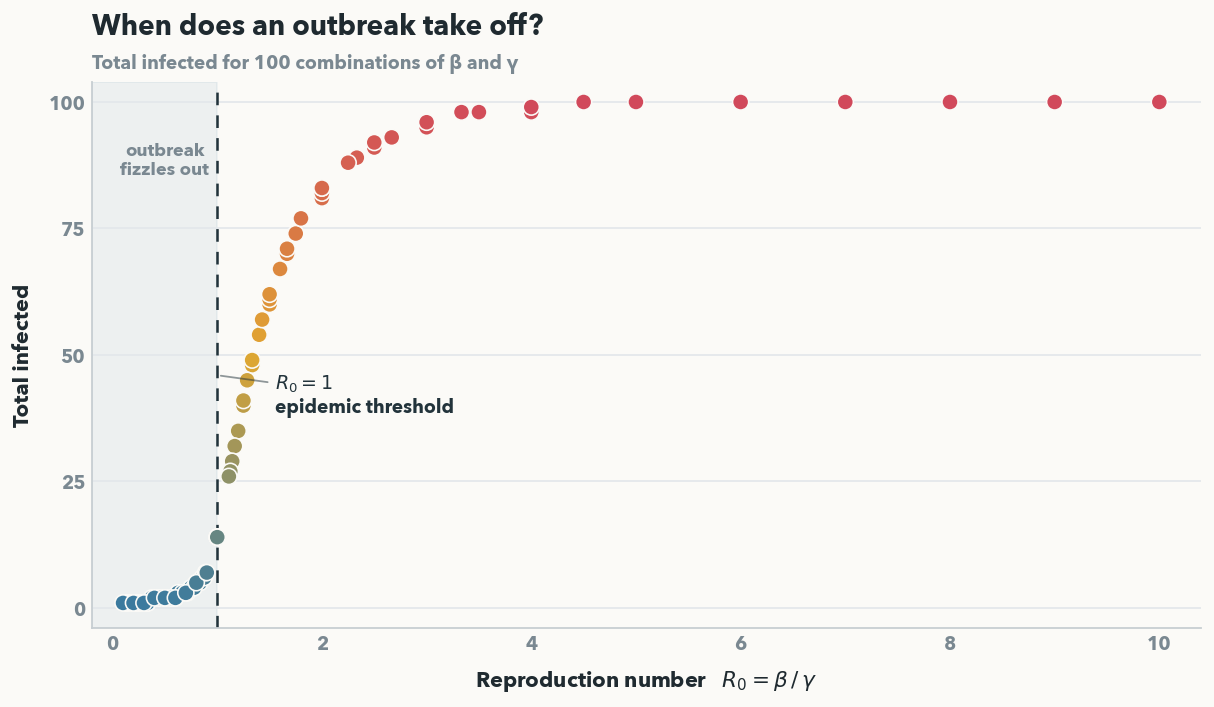

In [8]:
# Graphing the R_0 values.
repro_nums = np.array([record['repro_num'] for record in sir_results])
infected = np.array([record['total_infected'] for record in sir_results])
fig, ax = plt.subplots(figsize=(9.5, 5.6))

# Shade the regime where the outbreak never really takes off.
ax.axvspan(repro_nums.min() - 0.3, 1.0, color=PALETTE['s'], alpha=0.07, zorder=0)
ax.axvline(1.0, color=ACCENT, linestyle=(0, (5, 4)), linewidth=1.4, zorder=1)

ax.scatter(repro_nums, infected, c=infected, cmap=SEQ, s=80,
           edgecolor=PAPER, linewidth=0.9, zorder=3)

ax.annotate('$R_0 = 1$\nepidemic threshold', xy=(1.0, infected.max() * 0.46),
            xytext=(1.55, infected.max() * 0.42), fontsize=10.5, color=ACCENT,
            fontweight='bold', va='center',
            arrowprops=dict(arrowstyle='-', color=ACCENT, lw=1, alpha=0.5))
ax.text(0.5, infected.max() * 0.92, 'outbreak\nfizzles out', fontsize=10,
        color=MUTED, style='italic', ha='center', va='top')

titled(ax, 'When does an outbreak take off?',
       'Total infected for 100 combinations of β and γ')
ax.set_xlabel('Reproduction number   $R_0 = \\beta\\,/\\,\\gamma$')
ax.set_ylabel('Total infected')
ax.set_xlim(repro_nums.min() - 0.3, repro_nums.max() + 0.4)
ax.set_ylim(-4, 104)
ax.set_yticks([0, 25, 50, 75, 100])

plt.tight_layout()
plt.show()


## The SEIRS Model

Bjørnstad et al. (2021) introduced an augmented version of the SIR model to simulate the spread of COVID-19 more accurately. It introduced two new components:
1. The variation adds the Exposed state, where the virus is incubating in an individual before that individual gets sick and begins to spread the disease. 
2. The variation adds a loss of immunity, where recovered individuals transition back to being susceptible after a certain amount of time.
3. The variation adds births and deaths, both of which affect the total number of individuals in the population.

Here I'd like to demonstrate how the SEIRS model behaves with a toy population, then compare those results to both an equivalent SIR model and actual data collected from the 2020 COVID-19 pandemic.

In [9]:
# Let's again start by defining variables.
N = 100.0       # Total population
S_0 = 99.9      # Initial susceptible
E_0 = 0.1       # Initial exposed
I_0 = 0         # Initial infected
R_0 = 0         # Initial recovered

# Transition values taken from Fig 1 of the paper.
beta  = 0.299   # S->E rate
sigma = 0.143   # E->I rate
gamma = 0.071   # I->R rate
omega = 0.003   # R->S rate
mu    = 0.00004 # Natural birth/death rate
alpha = 0.00    # Covid death rate
num_days = 1000 # Simulation length

In [10]:
# Now we run the simulation for 100 timesteps.
seirs_data = {
    's': [S_0],
    'e': [E_0],
    'i': [I_0],
    'r': [R_0],
}

cum_infected = 0

for _ in range(num_days - 1):

    S_t = seirs_data['s'][-1]
    E_t = seirs_data['e'][-1]
    I_t = seirs_data['i'][-1]
    R_t = seirs_data['r'][-1]

    # Get deltas.
    dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
    det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
    dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t)
    drt = (gamma * I_t) - (omega * R_t) - (mu * R_t)

    # Apply deltas.
    S_t += dst
    E_t += det
    I_t += dit
    R_t += drt

    # Record new values.
    seirs_data['s'].append(S_t)
    seirs_data['e'].append(E_t)
    seirs_data['i'].append(I_t)
    seirs_data['r'].append(R_t)

    # Accumulate infected
    cum_infected += sigma * E_t

# Print basic results.
print(f'Total Infection Events: {round(cum_infected)}')
print(f'Stable Infected Population: {round(seirs_data['i'][-1])}')

Total Infection Events: 277
Stable Infected Population: 3


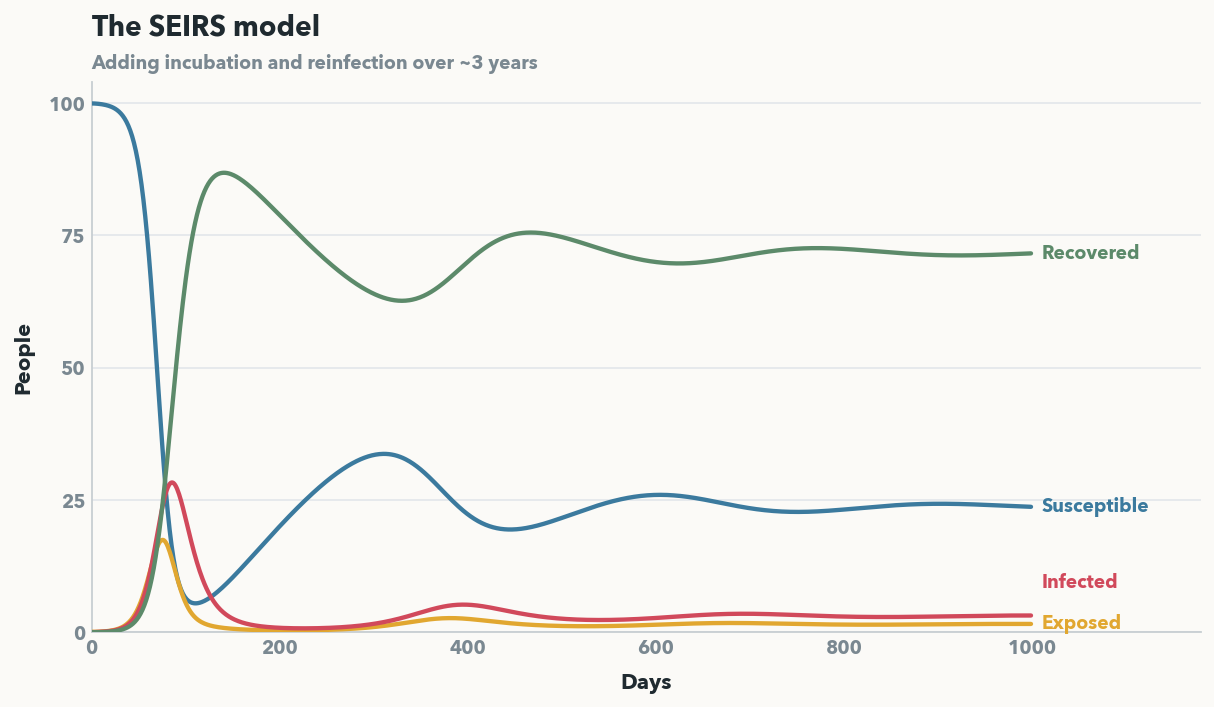

In [11]:
# Graph the data.
t = np.arange(num_days)
fig, ax = plt.subplots(figsize=(9.5, 5.6))

for key in ('s', 'e', 'i', 'r'):
    ax.plot(t, seirs_data[key], color=PALETTE[key], linewidth=2.4, zorder=3)

titled(ax, 'The SEIRS model',
       'Adding incubation and reinfection over ~3 years')
ax.set_xlabel('Days')
ax.set_ylabel('People')
ax.set_xlim(0, num_days)
ax.set_ylim(0, 104)
ax.set_yticks([0, 25, 50, 75, 100])

end_labels(ax, num_days + 10, [
    (seirs_data[k][-1], LABELS[k], PALETTE[k]) for k in ('s', 'e', 'i', 'r')
])
ax.set_xlim(0, num_days * 1.18)

plt.tight_layout()
plt.show()


### Demonstrating Intervention

The above examples of compartmental models assume that no action is being take to reduce the spread of the modeled disease. In this section, I want to see how the SEIRS model changes when we introduce a new state, Quarantined, to represent infected individuals being sequested to prevent further spread of COVID-19. By adjusting the new transition rate $\kappa$, we can determine what percent of infected individuals need to quarantine to effectively stop the spread of COVID-19.

In [12]:
# New variables for Q-SEIRS model simulation.
Q_0   = 0
kappa = 0.25   # Let's say 25% of people follow the quarantine

# Simulation time
seirs_data = {
    's': [S_0],
    'e': [E_0],
    'i': [I_0],
    'q': [Q_0],
    'r': [R_0],
}

cum_infected = 0

for t in range(num_days - 1):

    S_t = seirs_data['s'][-1]
    E_t = seirs_data['e'][-1]
    I_t = seirs_data['i'][-1]
    Q_t = seirs_data['q'][-1]
    R_t = seirs_data['r'][-1]

    # Get deltas.
    if t > 365:
        dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
        det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
        dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t) - (kappa * I_t)
        dqt = (kappa * I_t) - (gamma * Q_t) - ((mu + alpha) * Q_t)
        drt = (gamma * (I_t + Q_t)) - (omega * R_t) - (mu * R_t)
    else:
        dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
        det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
        dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t)
        dqt = 0.0
        drt = (gamma * I_t) - (omega * R_t) - (mu * R_t)

    # Apply deltas.
    S_t += dst
    E_t += det
    I_t += dit
    Q_t += dqt
    R_t += drt

    # Record new values.
    seirs_data['s'].append(S_t)
    seirs_data['e'].append(E_t)
    seirs_data['i'].append(I_t)
    seirs_data['q'].append(Q_t)
    seirs_data['r'].append(R_t)

    # Accumulate infected
    cum_infected += sigma * E_t

# Print basic results.
print(f'Total Infection Events: {round(cum_infected)}')

Total Infection Events: 138


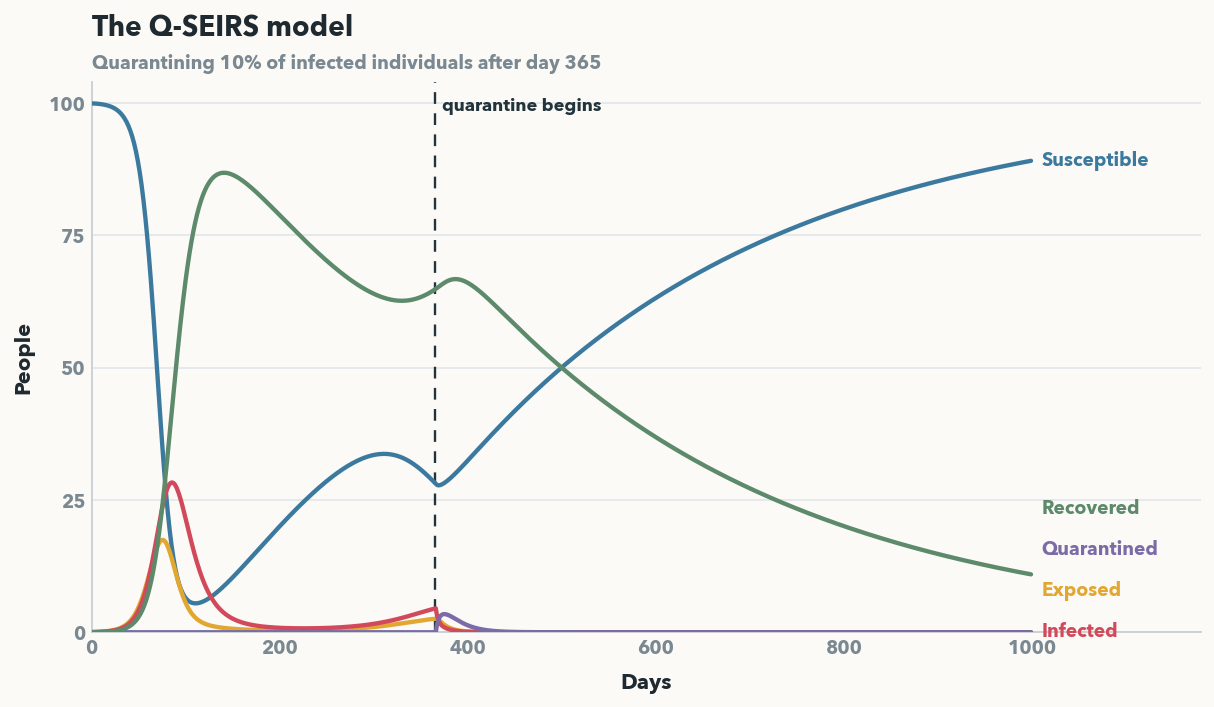

In [13]:
# Graph the data.
t = np.arange(num_days)
fig, ax = plt.subplots(figsize=(9.5, 5.6))

# Mark the day the quarantine policy switches on.
ax.axvline(365, color=ACCENT, linestyle=(0, (5, 4)), linewidth=1.3, zorder=1)
ax.text(365 + 8, 101, 'quarantine begins', fontsize=10, color=ACCENT,
        fontweight='bold', va='top', ha='left')

for key in ('s', 'e', 'i', 'q', 'r'):
    ax.plot(t, seirs_data[key], color=PALETTE[key], linewidth=2.4, zorder=3)

titled(ax, 'The Q-SEIRS model',
       'Quarantining 10% of infected individuals after day 365')
ax.set_xlabel('Days')
ax.set_ylabel('People')
ax.set_xlim(0, num_days)
ax.set_ylim(0, 104)
ax.set_yticks([0, 25, 50, 75, 100])

end_labels(ax, num_days + 10, [
    (seirs_data[k][-1], LABELS[k], PALETTE[k]) for k in ('s', 'e', 'i', 'q', 'r')
])
ax.set_xlim(0, num_days * 1.18)

plt.tight_layout()
plt.show()


### Quarantine Rate

In both SEIRS graphs, the infected population eventually stabilizes to a set value after enough time passes. Even with a quarantine in place, the disease never disappears entirely, it simply persists in a smaller percentage of the population. Due to reinfection, there are always new people who can contract the disease.

Below I model the relationship between $\kappa$ (the percentage of the population that quarantines after becoming infected) and the stable infected population (the percentage of the population infected at the end of the simulation) as well as the total number of infection events (how many times an exposed person became an infected person, including reinfections).

In [14]:
kappas = (np.array(range(300)) + 1) / 1000.0
qseirs_results = []

for curr_k in kappas:
    # Simulation time
    seirs_data = {
        's': [S_0],
        'e': [E_0],
        'i': [I_0],
        'q': [Q_0],
        'r': [R_0],
    }

    cum_infected = 0

    for t in range(num_days - 1):

        S_t = seirs_data['s'][-1]
        E_t = seirs_data['e'][-1]
        I_t = seirs_data['i'][-1]
        Q_t = seirs_data['q'][-1]
        R_t = seirs_data['r'][-1]

        # Get deltas.
        if t > 365:
            dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
            det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
            dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t) - (curr_k * I_t)
            dqt = (curr_k * I_t) - (gamma * Q_t) - ((mu + alpha) * Q_t)
            drt = (gamma * (I_t + Q_t)) - (omega * R_t) - (mu * R_t)
        else:
            dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
            det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
            dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t)
            dqt = 0.0
            drt = (gamma * I_t) - (omega * R_t) - (mu * R_t)

        # Apply deltas.
        S_t += dst
        E_t += det
        I_t += dit
        Q_t += dqt
        R_t += drt

        # Record new values.
        seirs_data['s'].append(S_t)
        seirs_data['e'].append(E_t)
        seirs_data['i'].append(I_t)
        seirs_data['q'].append(Q_t)
        seirs_data['r'].append(R_t)

        # Accumulate infected
        cum_infected += sigma * E_t

    # Store data for this run.
    qseirs_results.append({
        'k': curr_k,
        'stable_infected': I_t + Q_t,   # Quarantined individuals are also infected.
        'cum_infected': cum_infected,
    })

print(qseirs_results[-1])

{'k': 0.3, 'stable_infected': 6.187499596175248e-15, 'cum_infected': 137.62367202379895}


Let's see if we can find the inflection point using a modified version of the paper's suggested R_0 value. Remember that for an outbreak to stay under control $R_0 < 1$. Let's use that same logic to see what value of $\kappa$ is needed to keep the outbreak under control, using values specific to COVID.

$$
\begin{align}
    R_0 &= [\sigma / ( \sigma + \mu ) ] \times [\beta / ( \gamma + \mu + \alpha + \kappa )] \\
    R_0 / [\sigma / ( \sigma + \mu ) ] &= \beta / ( \gamma + \mu + \alpha + \kappa ) \\
    R_0 \times ( \gamma + \mu + \alpha + \kappa ) &= \beta \times [\sigma / ( \sigma + \mu ) ] \\
    \kappa &= [(\beta \times [\sigma / ( \sigma + \mu ) ]) - (R_0 \times [ \gamma + \mu + \alpha])] / R_0
\end{align}
$$

In [15]:
# Let's compute the minimum value of kappa needed for the infection to stay under control.
critical_kappa = (beta * (sigma / (sigma + mu)) - (1 * (gamma + mu + alpha))) / 1
print(f'Critical Kappa: {critical_kappa}')

Critical Kappa: 0.22787638702460844


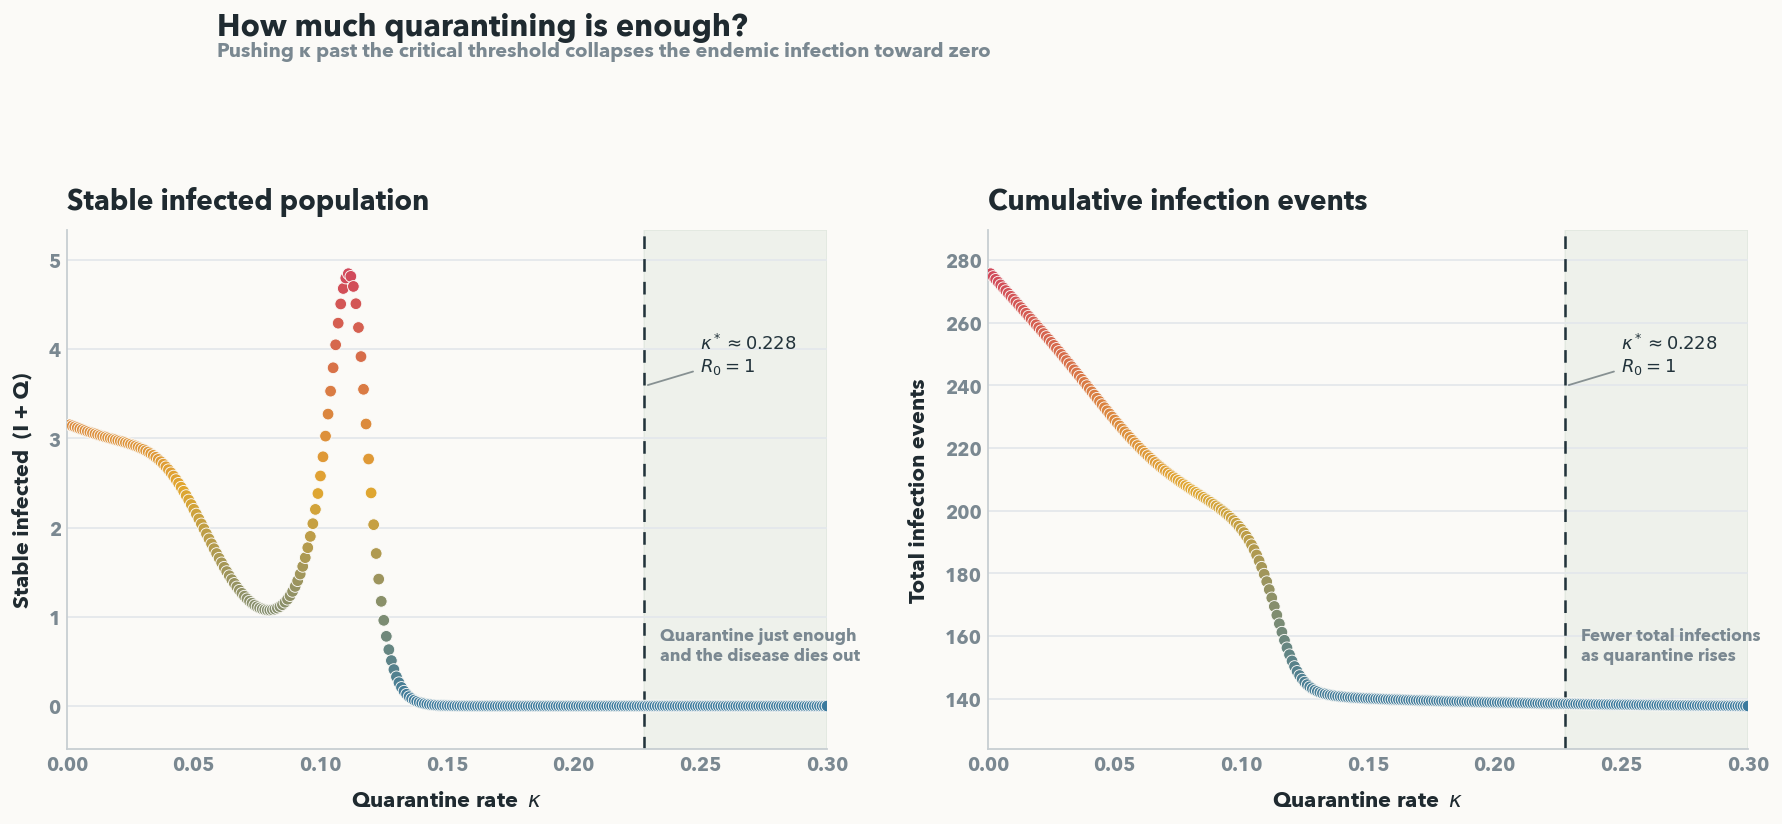

In [16]:
# Graphing the kappa sweep.
kappa_vals = np.array([record['k'] for record in qseirs_results])
stable = np.array([record['stable_infected'] for record in qseirs_results])
cumulative = np.array([record['cum_infected'] for record in qseirs_results])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6.2))

panels = [
    (ax1, stable, 'Stable infected population', 'Stable infected  (I + Q)',
     'Quarantine just enough\nand the disease dies out'),
    (ax2, cumulative, 'Cumulative infection events', 'Total infection events',
     'Fewer total infections\nas quarantine rises'),
]

for ax, ydata, title, ylabel, note in panels:
    # Shade the regime that keeps the outbreak under control.
    ax.axvspan(critical_kappa, kappa_vals.max(), color=PALETTE['r'],
               alpha=0.08, zorder=0)
    ax.axvline(critical_kappa, color=ACCENT, linestyle=(0, (5, 4)),
               linewidth=1.4, zorder=1)
    ax.scatter(kappa_vals, ydata, c=ydata, cmap=SEQ, s=42,
               edgecolor=PAPER, linewidth=0.5, zorder=3)
    titled(ax, title)
    ax.set_xlabel('Quarantine rate  $\\kappa$')
    ax.set_ylabel(ylabel)
    ax.set_xlim(0, kappa_vals.max())
    ax.margins(y=0.10)
    lo, hi = ax.get_ylim()
    span = hi - lo
    ax.annotate(f'$\\kappa^* \\approx {critical_kappa:.3f}$\n$R_0 = 1$',
                xy=(critical_kappa, lo + span * 0.70),
                xytext=(critical_kappa + 0.022, lo + span * 0.76), fontsize=10,
                color=ACCENT, fontweight='bold', va='center',
                arrowprops=dict(arrowstyle='-', color=ACCENT, lw=1, alpha=0.5))
    ax.text(critical_kappa + 0.006, lo + span * 0.20, note, fontsize=9.5,
            color=MUTED, style='italic', va='center', ha='left')

fig.suptitle('How much quarantining is enough?', x=0.125, y=1.02,
             ha='left', fontsize=17, fontweight='bold', color=INK)
fig.text(0.125, 0.965, 'Pushing κ past the critical threshold collapses the '
         'endemic infection toward zero', ha='left', fontsize=11, color=MUTED)

plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()


What we find is that if a critical percentage of the population quarantines 1 day after discovering they've been exposed to COVID-19, the infected population stablizes at a low number. Note that this model assumes that quarantined individuals are perfectly isolated and do not transmit COVID to anyone else after quarantining. In reality, many people spread COVID to the people they lived with or simply broke quarantine while they were still infectious. Additionally, our model assumes that people who quarantine do so the day after they become exposed. In reality, it usually takes more than 1 day for people to discover that they've been exposed.

Despite the added realism of the SEIRS model and our Q-SEIRS variant, there are still too many assumptions and unmodeled behaviors missing from our simulations. To better capture the nuances of how diseases spread, we need to test out agent-based methods.

Also note that our simulation triggers the quarantine 1 year after the first infection. In the US, lockdown was declared 59 days after the first infection was discovered, when only 0.00000475433 of the population was infected. By waiting for the infected population to grow, my simulation lets us track the effectiveness of quarantine much more effectively. Here's what the graph would look like if we followed the our timeline.

In [28]:
# Simulation time
N = 342600000.0 # Estimated US population
seirs_data = {
    's': [N - 1.0],
    'e': [0.0],
    'i': [35.0],
    'q': [Q_0],
    'r': [R_0],
}

cum_infected = 0

for t in range(num_days - 1):

    S_t = seirs_data['s'][-1]
    E_t = seirs_data['e'][-1]
    I_t = seirs_data['i'][-1]
    Q_t = seirs_data['q'][-1]
    R_t = seirs_data['r'][-1]

    # Get deltas.
    if t > 59:
        dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
        det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
        dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t) - (kappa * I_t)
        dqt = (kappa * I_t) - (gamma * Q_t) - ((mu + alpha) * Q_t)
        drt = (gamma * (I_t + Q_t)) - (omega * R_t) - (mu * R_t)
    else:
        dst = (mu * N) + (omega * R_t) - (beta * S_t * I_t / N) - (mu * S_t)
        det = (beta * S_t * I_t / N) - (sigma * E_t) - (mu * E_t)
        dit = (sigma * E_t) - (gamma * I_t) - ((mu + alpha) * I_t)
        dqt = 0.0
        drt = (gamma * I_t) - (omega * R_t) - (mu * R_t)

    # Apply deltas.
    S_t += dst
    E_t += det
    I_t += dit
    Q_t += dqt
    R_t += drt

    # Record new values.
    seirs_data['s'].append(S_t)
    seirs_data['e'].append(E_t)
    seirs_data['i'].append(I_t)
    seirs_data['q'].append(Q_t)
    seirs_data['r'].append(R_t)

    # Accumulate infected
    cum_infected += sigma * E_t

    if t == 59:
        print('Quarantine Begins')
        print(f'Total Infections so far: {round(cum_infected)}')

# Print basic results.
print(f'Total Infection Events: {round(cum_infected)}')

Quarantine Begins
Total Infections so far: 13547
Total Infection Events: 238163


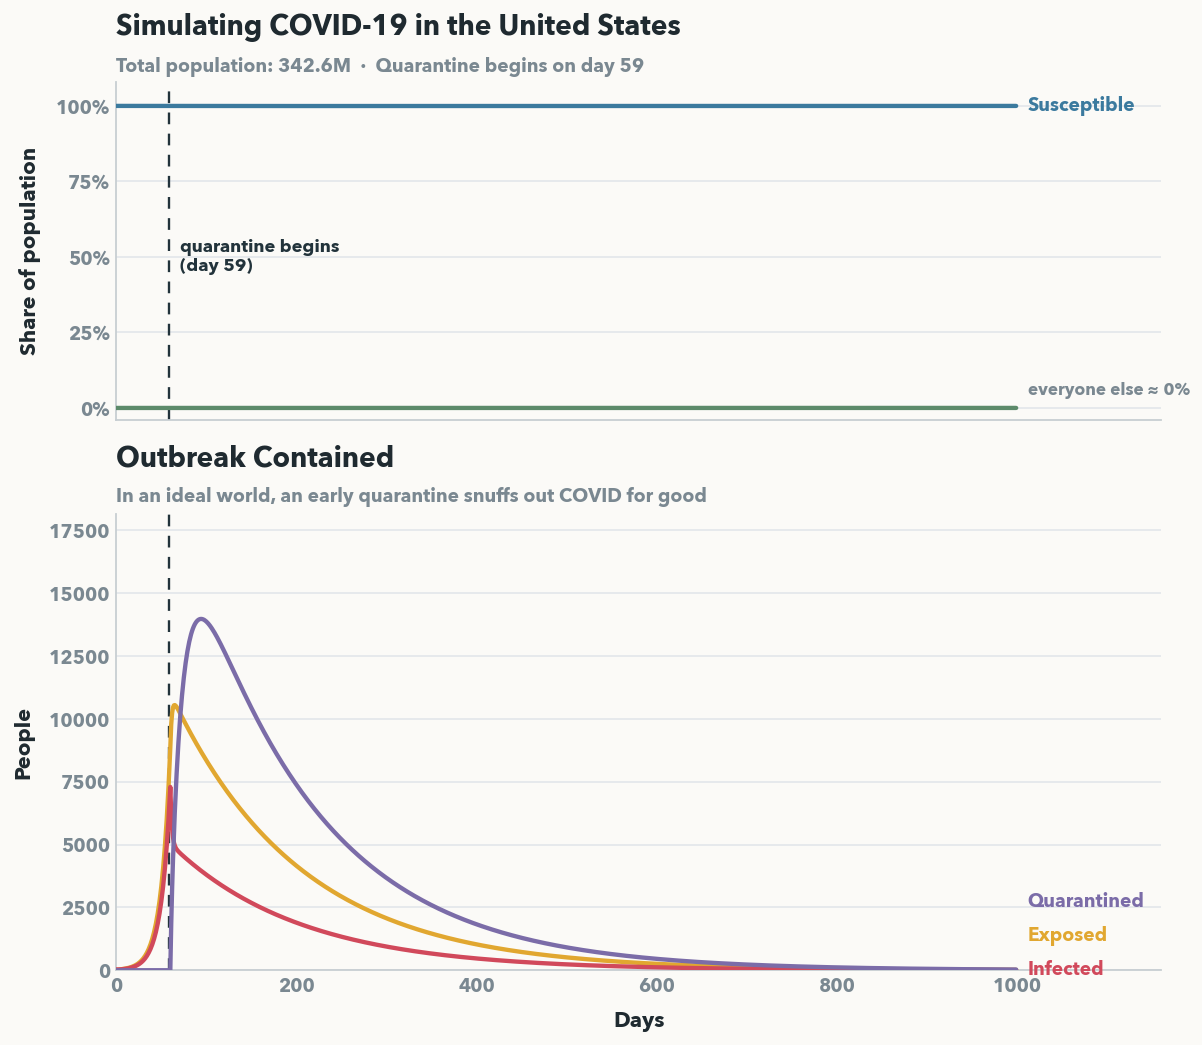

In [29]:
# Graph the data.
# At a population of 342.6M the outbreak peaks at a few dozen people, so a single
# 0-100 axis is hopeless. We split the story across two panels that share a
# timeline: the whole population (as a share of the US) and a zoom into the
# handful of people who are actually infected.
t = np.arange(num_days)
fig, (axp, axz) = plt.subplots(2, 1, figsize=(9.5, 8.2),
                               height_ratios=[1, 1.35], sharex=True)

# ── Top: the whole US population, as a share ─────────────────────────────────
for key in ('s', 'r'):
    axp.plot(t, 100 * np.array(seirs_data[key]) / N,
             color=PALETTE[key], linewidth=2.4, zorder=3)
axp.axvline(59, color=ACCENT, linestyle=(0, (5, 4)), linewidth=1.3, zorder=1)
axp.text(59 + 12, 50, 'quarantine begins\n(day 59)', fontsize=10, color=ACCENT,
         fontweight='bold', va='center', ha='left')
titled(axp, 'Simulating COVID-19 in the United States',
       'Total population: 342.6M  ·  Quarantine begins on day 59')
axp.set_ylabel('Share of population')
axp.set_ylim(-4, 108)
axp.set_yticks([0, 25, 50, 75, 100])
axp.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
end_labels(axp, num_days + 12, [(100 * seirs_data['s'][-1] / N, 'Susceptible', PALETTE['s'])])
axp.text(num_days + 12, 6, 'everyone else ≈ 0%', fontsize=9.5, color=MUTED,
         style='italic', va='center', ha='left')

# ── Bottom: zoom into the active outbreak, counted in people ─────────────────
for key in ('e', 'i', 'q'):
    axz.plot(t, seirs_data[key], color=PALETTE[key], linewidth=2.4, zorder=3)
axz.axvline(59, color=ACCENT, linestyle=(0, (5, 4)), linewidth=1.3, zorder=1)
peak_active = max(max(seirs_data[k]) for k in ('e', 'i', 'q'))
titled(axz, 'Outbreak Contained',
       'In an ideal world, an early quarantine snuffs out COVID for good')
axz.set_xlabel('Days')
axz.set_ylabel('People')
axz.set_ylim(0, peak_active * 1.3)
axz.set_xlim(0, num_days * 1.16)
end_labels(axz, num_days + 12,
           [(seirs_data[k][-1], LABELS[k], PALETTE[k]) for k in ('e', 'i', 'q')])

plt.tight_layout()
plt.show()
